**NOTICE:**  
The U.S. Army Corps of Engineers, Risk Management Center (USACE-RMC) makes no guarantees about the results, or appropriateness of outputs, obtained from Numerics.

# 08. Time Series Analysis
This notebook covers time series data manipulation and analysis.

## What You'll Learn

- Creating and manipulating TimeSeries objects
- Smoothing techniques (moving average, exponential, Gaussian)
- Block operations (annual max, monthly mean)
- Interpolation and resampling
- Trend analysis
- Seasonal decomposition
- Working with hydrologic data

## Real-World Applications

Streamflow analysis, climate data, water quality monitoring.

## Set Up

In [29]:
import pythonnet
pythonnet.load("coreclr")

import clr
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from datetime import datetime
from System import DateTime

# Load Numerics DLL
dll_path = Path(r"C:\GIT\Numerics\Numerics\bin\Debug\net8.0\Numerics.dll")
clr.AddReference(str(dll_path))

from Numerics.Data import TimeSeries,  TimeInterval, BlockFunctionType,TimeSeriesDownload
from Numerics.Distributions import GammaDistribution
from helper_functions import convert_to_dotnet_array

print("✓ Setup complete")

✓ Setup complete


## Helper Functions
We define some helper functions to switch between .NET, Python, and TimeSeries objects.

In [22]:
def ts_to_arrays(ts):
    dates = [o.Index for o in ts]
    values = [o.Value for o in ts]
    return np.array(dates), np.array(values)

def ts_to_python_time(dates):
    return [datetime(o.Year, o.Month, o.Day, o.Hour, o.Minute, o.Second) for o in dates]

## 1. Creating TimeSeries Objects
We will construct a regular daily time series and inspect its basic statistical properties.

Base TimeSeries summary


,Metric,Value
0,Sample Size,40
1,Start Date,1/1/2020 12:00:00 AM
2,End Date,2/9/2020 12:00:00 AM
3,Mean,5.5
4,Min,1.0
5,Max,10.0


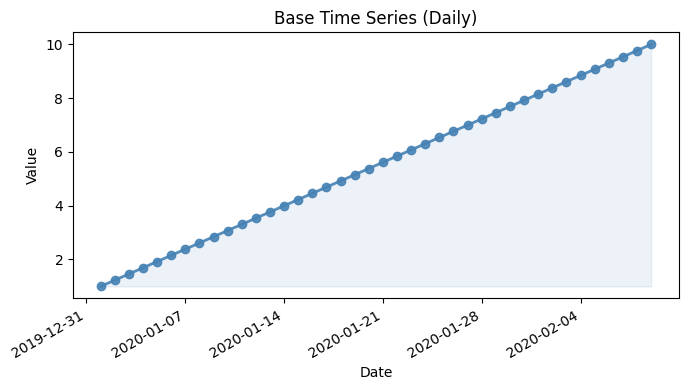

In [23]:
np.random.seed(42)
start = DateTime(2020, 1, 1)
values = np.linspace(1, 10, 40)
values_net = convert_to_dotnet_array(values.tolist())
ts = TimeSeries(TimeInterval.OneDay, start, values_net)
dates, vals = ts_to_arrays(ts)

ts_df = pd.DataFrame({'Metric':['Sample Size','Start Date','End Date','Mean','Min','Max'],'Value':
                      [len(ts),ts.StartDate,ts.EndDate,vals.mean(),vals.min(),vals.max()]})
print('Base TimeSeries summary')
display(ts_df)

# Convert to Python for plotting
py_ts = ts_to_python_time(dates)



fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(py_ts, vals, color='steelblue', linewidth=2, marker="o", alpha=0.9)
ax.fill_between(py_ts, vals, np.min(vals), color='steelblue', alpha=0.10)
ax.set_title("Base Time Series (Daily)")
ax.set_xlabel("Date")
ax.set_ylabel("Value")
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 2. Smoothing
We will explore 2 ways we can smooth noisy data
1. **Moving Average:** Apply a rolling mean to reduce high-frequency variability while preserving trend.
2. **Moving Sum:** Compute rolling accumulation over a fixed window, useful for volume-based metrics.

Smoothing summary


,Metric,Value
0,Original Mean,42.828563
1,Smoothed Mean (MA),42.844226
2,First MA Value,43.583918
3,First Moving Sum,130.751755


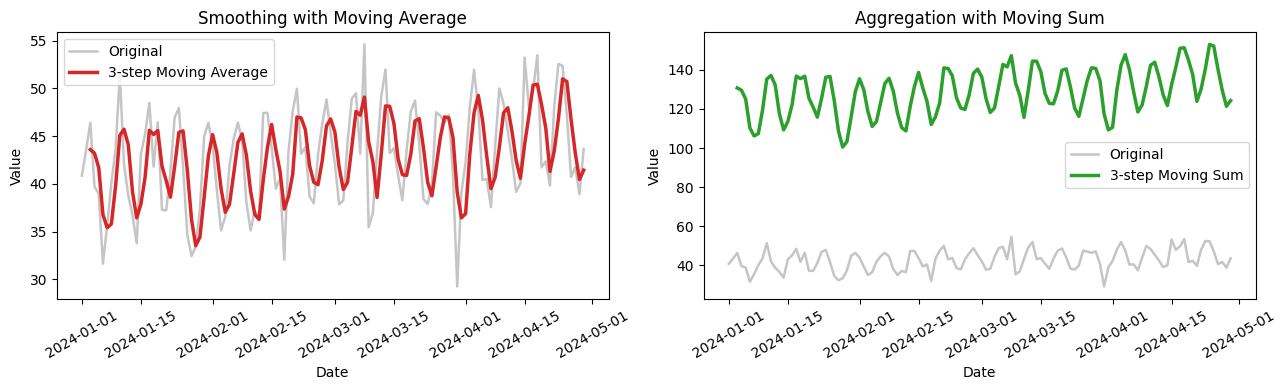

In [28]:
# Create synethtic data with weekly cycle and spikes
np.random.seed(12)
n = 120
t = np.arange(n)
baseline = 40 + 0.05*t
weekly = 6*np.sin(2*np.pi*t/7)
noise = np.random.normal(0, 1.8, n)

values = baseline + weekly + noise
values[[18, 42, 67, 89, 105]] += np.array([10, -8, 12, -10, 9])  # anomalies

start = DateTime(2024, 1, 1)
ts = TimeSeries(TimeInterval.OneDay, start, convert_to_dotnet_array(values.tolist()))
dates, vals = ts_to_arrays(ts)
py_ts = ts_to_python_time(dates)

# Calculate 3 day moving average
ma = ts.MovingAverage(period=3)
ma_dates, ma_vals = ts_to_arrays(ma)
py_ma_dates = ts_to_python_time(ma_dates)

# Calculate 3 day moving sum
ms = ts.MovingSum(period=3)
ms_dates, ms_vals = ts_to_arrays(ms)
py_ms_dates = ts_to_python_time(ms_dates)

smooth_df = pd.DataFrame({'Metric':['Original Mean','Smoothed Mean (MA)','First MA Value','First Moving Sum'],'Value':
                          [vals.mean(),ma_vals.mean(),ma_vals[0],ms_vals[0]]})
print('Smoothing summary')
display(smooth_df)

# Graph!
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=False)
# Left: MA
axes[0].plot(py_ts, vals, color="gray", alpha=0.45, linewidth=1.8, label="Original")
axes[0].plot(py_ma_dates, ma_vals, color="#d62728", linewidth=2.5, label="3-step Moving Average")
axes[0].set_title("Smoothing with Moving Average")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Value")
axes[0].legend()

# Right: MS
axes[1].plot(py_ts, vals, color="gray", alpha=0.45, linewidth=1.8, label="Original")
axes[1].plot(py_ms_dates, ms_vals, color="#2ca02c", linewidth=2.5, label="3-step Moving Sum")
axes[1].set_title("Aggregation with Moving Sum")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Value")
axes[1].legend()

for ax in axes:
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## 3. Block Operations

Aggregate high-resolution data into calendar-aligned blocks using reduction operators.
1. **Annual Maximums:** Extract annual peak flows for flood frequency analysis.
2. **Monthly Maximums:** Calculate monthly average flows.


Annual maxima


,Year Index,Annual Max
0,1,18.732
1,2,20.767
2,3,22.270


Monthly peaks


,Month Index,Monthly Peak
0,1,15.135
1,2,16.348
2,3,12.288
3,4,15.875
4,5,18.218
5,6,11.471
6,7,18.732
7,8,16.423
8,9,16.240
9,10,11.565


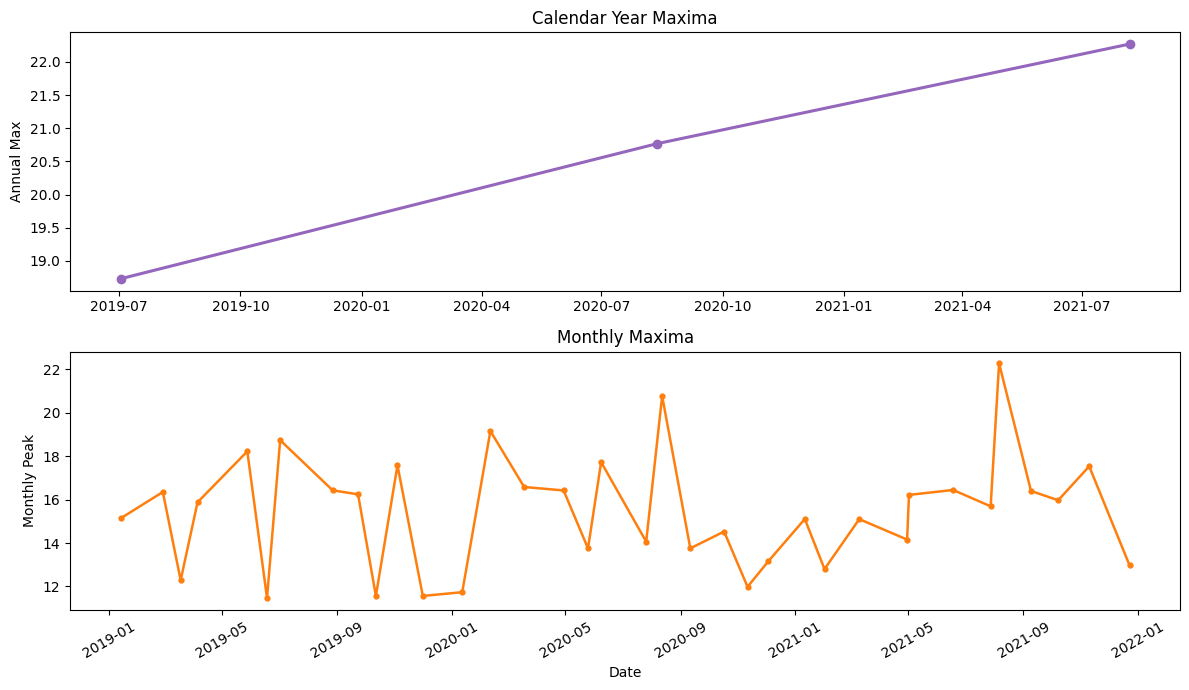

In [ ]:
start = DateTime(2019, 1, 1)
values = GammaDistribution(2,3).GenerateRandomValues(1095,123)
daily = TimeSeries(TimeInterval.OneDay, start, values)

annual_max = daily.CalendarYearSeries(blockFunction=BlockFunctionType.Maximum)
annual_dates, annual_vals = ts_to_arrays(annual_max)
py_annual_dates = ts_to_python_time(annual_dates)

monthly_max = daily.MonthlySeries(BlockFunctionType.Maximum)
mm_dates, mm_vals = ts_to_arrays(monthly_max)
py_mm_dates = ts_to_python_time(mm_dates)

annual_tbl = pd.DataFrame({'Year Index': np.arange(1, len(annual_vals)+1), 'Annual Max': np.round(annual_vals, 3)})
monthly_tbl = pd.DataFrame({'Month Index': np.arange(1, len(mm_vals)+1), 'Monthly Peak': np.round(mm_vals, 3)})
print('Annual maxima')
display(annual_tbl)
print('Monthly peaks')
display(monthly_tbl)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=False)

axes[0].plot(py_annual_dates, annual_vals, marker="o", linewidth=2.2, color="#9467bd")
axes[0].set_title("Calendar Year Maxima")
axes[0].set_ylabel("Annual Max")

axes[1].plot(py_mm_dates, mm_vals, marker="o", markersize=3.5, linewidth=1.8, color="#ff7f0e")
axes[1].set_title("Monthly Maxima")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Monthly Peak")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## 4. Interpolation
Interpolate short gaps in the time series while preserving surrounding trends.

Interpolation summary


,Metric,Value
0,Missing before,5
1,Missing after,0


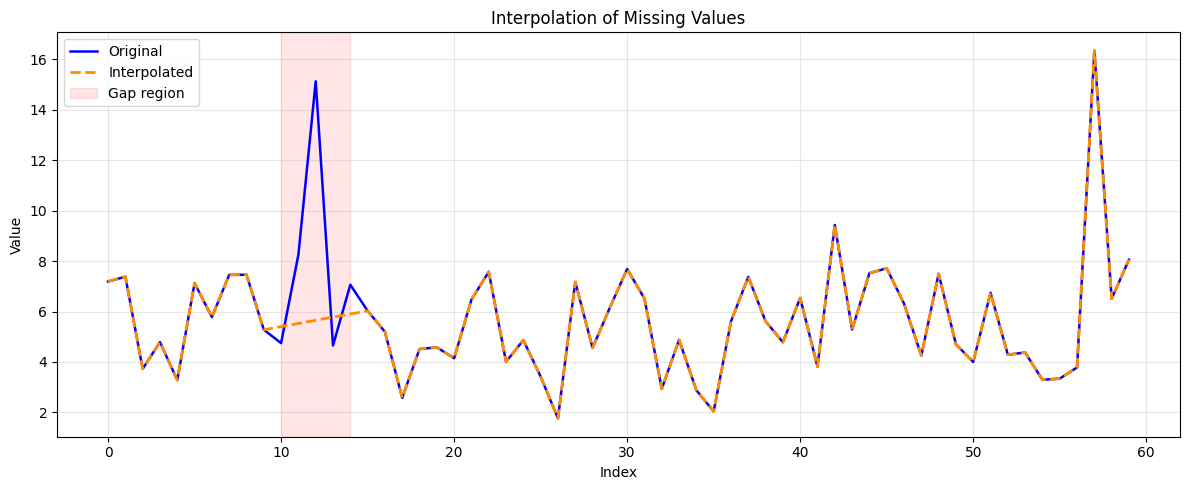

In [46]:
start = DateTime(2019, 1, 1)
values = GammaDistribution(2,3).GenerateRandomValues(60,123)
daily = TimeSeries(TimeInterval.OneDay, start, values)
_, daily_vals = ts_to_arrays(daily)

daily_vals_gap = daily_vals

daily_vals_gap[10:15] = np.nan
daily_vals_gap = convert_to_dotnet_array(daily_vals_gap.tolist())

ts_gap = TimeSeries(TimeInterval.OneDay, start, daily_vals_gap)
missing_before = sum(np.isnan(o.Value) for o in ts_gap)
ts_gap.InterpolateMissingData(maxNumberOfMissing=10)
missing_after = sum(np.isnan(o.Value) for o in ts_gap)

interp_dates, interp_vals = ts_to_arrays(ts_gap)
py_interp_dates = ts_to_python_time(interp_dates)
interp_df = pd.DataFrame({'Metric':['Missing before','Missing after'],'Value':[missing_before, missing_after]})
print('Interpolation summary')
display(interp_df)

plt.figure(figsize=(12, 5))
plt.plot(np.arange(len(daily_vals)), values, color='blue', linewidth=1.8, label='Original')
plt.plot(np.arange(len(interp_vals)), interp_vals, color='darkorange', linestyle='--', linewidth=2, label='Interpolated')
plt.axvspan(10, 14, color="red", alpha=0.10, label="Gap region")
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Interpolation of Missing Values')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 5. Resampling
Resampling converts a series to a different time interval (for example daily to hourly) using interpolation or aggregation rules.
Use it to align data with model time steps or reporting intervals.

Hourly resampling summary


,Metric,Value
0,Hourly Count,17497.000000
1,Hourly Mean,6.148152
2,Hourly Std,3.422918


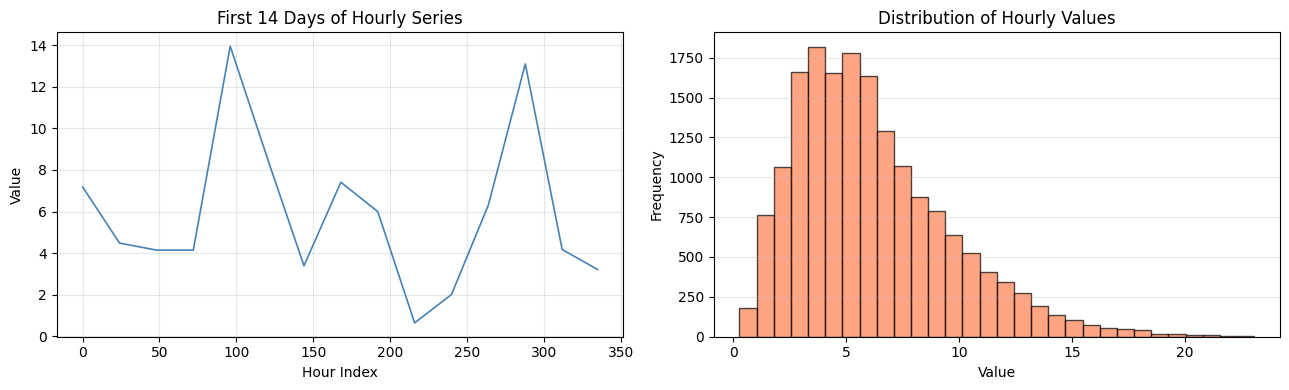

In [ ]:
hourly = daily.ConvertTimeInterval(
    TimeInterval.OneHour,
    average=True
)

_, hourly_vals = ts_to_arrays(hourly)
resample_df = pd.DataFrame({'Metric':['Hourly Count','Hourly Mean','Hourly Std'],'Value':
                            [len(hourly_vals), hourly_vals.mean(), hourly_vals.std()]})
print('Hourly resampling summary')
display(resample_df)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(hourly_vals[:24*14], linewidth=1.2, color='steelblue')
axes[0].set_title('First 14 Days of Hourly Series')
axes[0].set_xlabel('Hour Index')
axes[0].set_ylabel('Value')
axes[0].grid(True, alpha=0.3)

axes[1].hist(hourly_vals, bins=30, color='coral', alpha=0.7, edgecolor='black')
axes[1].set_title('Distribution of Hourly Values')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout(); plt.show()

## 6. USGS Data Download Integration
Download observed streamflow data and apply immediate statistical analysis. We will plot this data in the next section.

In [47]:
# Site number for Mississippi River at St. Louis, MO
site = "07010000"
# Check to see if device is connected to the internet
if TimeSeriesDownload.IsConnectedToInternet:
    task = TimeSeriesDownload.FromUSGS(site)
    result = task.Result
    ts = result.Item1
else:
    ts = None
    print("No internet connection detected. Skipping USGS download.")

if ts is not None:
    _, q_vals = ts_to_arrays(ts)
    # Check for NaN values
    valid = q_vals[~np.isnan(q_vals)]
    usgs_df = pd.DataFrame({'Metric':['USGS Sample Size','Valid Samples','Mean Flow','Peak Flow'],'Value':
                            [len(q_vals),len(valid),np.mean(valid),np.max(valid)]})
    print('USGS download summary')
    display(usgs_df)

    # Calculate monthly peaks
    monthly_max = ts.MonthlySeries(BlockFunctionType.Maximum)
    mm_dates, mm_vals = ts_to_arrays(monthly_max)
    monthly_df = pd.DataFrame({'Month Index': np.arange(1, len(mm_vals)+1), 'Monthly Peak': np.round(mm_vals, 3)})
    print('Monthly peaks from downloaded series')
    display(monthly_df)
else:
    print('USGS download unavailable in this environment.')

USGS download summary


,Metric,Value
0,USGS Sample Size,6.031400e+04
1,Valid Samples,5.994600e+04
2,Mean Flow,1.906882e+05
3,Peak Flow,1.050000e+06


Monthly peaks from downloaded series


,Month Index,Monthly Peak
0,1,41400.0
1,2,170000.0
2,3,257000.0
3,4,353000.0
4,5,466000.0
...,...,...
1965,1966,120000.0
1966,1967,94800.0
1967,1968,88000.0
1968,1969,134000.0


## 7. Plotting Time Series
Using out USGS data we will plot it to inspect trend, seasonality, variability, and anomalies. This is important to check before fitting models.
This section overlays raw and transformed series for visual diagnostics.

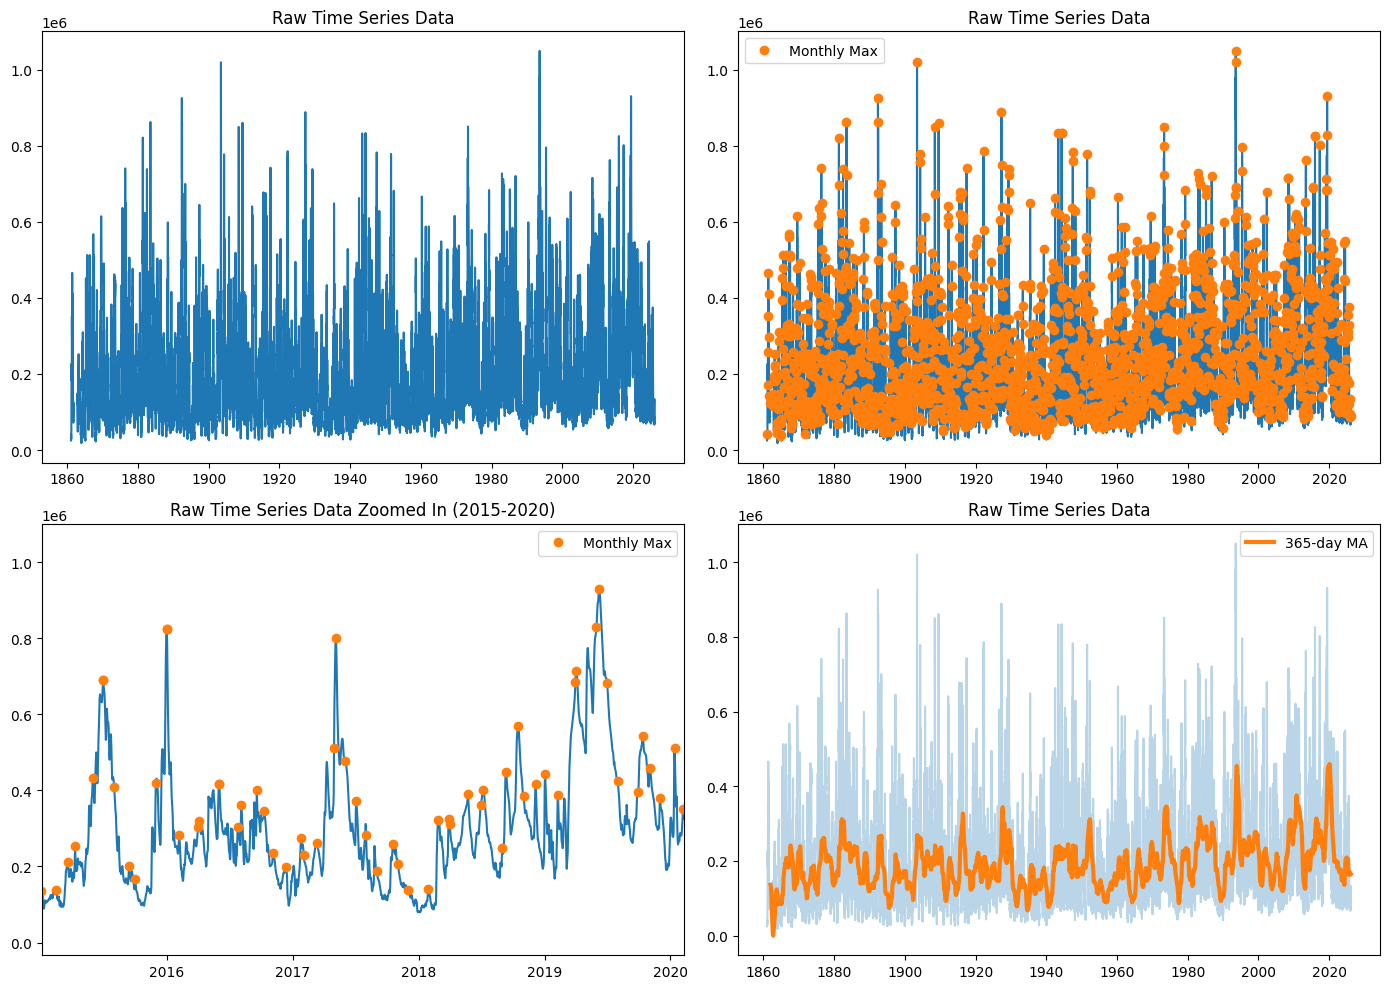

In [55]:
# Raw data
dates, vals = ts_to_arrays(ts)
# Convert .NET DateTime to Python datetime
py_dates = ts_to_python_time(dates)
py_mm_dates = ts_to_python_time(mm_dates)

# Moving average over the past year
ma = ts.MovingAverage(period=365)

# Convert time series object to arrays for plotting
ma_dates, ma_vals = ts_to_arrays(ma)
# Convert .NET DateTime to Python datetime
py_ma_dates = [datetime(o.Year, o.Month, o.Day, o.Hour, o.Minute, o.Second) for o in ma_dates]  

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(py_dates, vals)
axes[0,0].set_title("Raw Time Series Data")

plt.sca(axes[0,1])
axes[0,1].plot(py_dates, vals)
axes[0,1].plot(py_mm_dates, mm_vals, "o", label="Monthly Max")
axes[0,1].set_title("Raw Time Series Data")
axes[0,1].legend()

plt.sca(axes[1,0])
axes[1,0].plot(py_dates, vals)
axes[1,0].plot(py_mm_dates, mm_vals, "o", label="Monthly Max")
axes[1,0].set_title("Raw Time Series Data Zoomed In (2015-2020)")
axes[1,0].set_xlim([datetime(2015,1,3), datetime(2020,2,9)])
axes[1,0].legend()

plt.sca(axes[1,1])
axes[1,1].plot(py_dates, vals, alpha=0.3)
axes[1,1].plot(py_ma_dates, ma_vals, linewidth=3, label ="365-day MA")
axes[1,1].set_title("Raw Time Series Data")
axes[1,1].legend()

plt.tight_layout()
plt.show()


# Summary

You've learned:

✓ Creating and manipulating TimeSeries objects     
✓ Smoothing: moving average, moving sum        
✓ Block operations: annual max, monthly means      
✓ Interpolation        
✓ Resampling       
✓ USGS Data Integration        
✓ Plotting TimeSeries data     

## Key Takeaways

1. **Smoothing reduces noise** - Choose window based on application
2. **Block operations summarize** - Annual max for floods, monthly means for patterns
3. **Interpolation fills gaps** - Use appropriate method for data type
4. **Resampling:**

## Next Steps

- **02_distribution_fitting.ipynb** - Fit distributions to annual max series
- **07_statistics.ipynb** - Statistical tests on time series

## Exercise

1. Create a time series with seasonal pattern
2. Apply 3 different smoothing methods
3. Extract annual maximums
5. Which method best captures the signal?